In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


In [3]:
os.chdir('//Users//sushantsolanki//Desktop//all folders//Finance project')

In [4]:
df=pd.read_csv('Credit_card_transactions_India_Enriched.csv')

In [5]:
df

,index,City,City_Clean,City_Tier,Date,Year,Month,Month_Name,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
0,0,"Delhi, India",Delhi,Metro,2014-10-29,2014,10,October,2014Q4,Wednesday,False,True,Gold,Bills,F,82475,Medium
1,1,"Greater Mumbai, India",Greater Mumbai,Metro,2014-08-22,2014,8,August,2014Q3,Friday,False,False,Platinum,Bills,F,32555,Low
2,2,"Bengaluru, India",Bengaluru,Metro,2014-08-27,2014,8,August,2014Q3,Wednesday,False,False,Silver,Bills,F,101738,Medium
3,3,"Greater Mumbai, India",Greater Mumbai,Metro,2014-04-12,2014,4,April,2014Q2,Saturday,True,False,Signature,Bills,F,123424,Medium
4,4,"Bengaluru, India",Bengaluru,Metro,2015-05-05,2015,5,May,2015Q2,Tuesday,False,False,Gold,Bills,F,171574,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26047,26047,"Kolkata, India",Kolkata,Tier-1,2014-06-22,2014,6,June,2014Q2,Sunday,True,False,Silver,Travel,F,128191,Medium
26048,26048,"Pune, India",Pune,Tier-1,2014-08-03,2014,8,August,2014Q3,Sunday,True,False,Signature,Travel,M,246316,Very High
26049,26049,"Hyderabad, India",Hyderabad,Tier-1,2015-01-16,2015,1,January,2015Q1,Friday,False,False,Silver,Travel,M,265019,Very High
26050,26050,"Kanpur, India",Kanpur,Tier-2,2014-09-14,2014,9,September,2014Q3,Sunday,True,False,Silver,Travel,M,88174,Medium


# EDA (Exploratery Data Analysis)

## checking shape of data set

In [6]:
df.shape

(26052, 17)

In [7]:
df.columns

Index(['index', 'City', 'City_Clean', 'City_Tier', 'Date', 'Year', 'Month',
       'Month_Name', 'Quarter', 'Weekday', 'Is_Weekend', 'Festive_Season',
       'Card_Type', 'Exp_Type', 'Gender', 'Amount', 'Amount_Bucket'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   index           26052 non-null  int64 
 1   City            26052 non-null  object
 2   City_Clean      26052 non-null  object
 3   City_Tier       26052 non-null  object
 4   Date            26052 non-null  object
 5   Year            26052 non-null  int64 
 6   Month           26052 non-null  int64 
 7   Month_Name      26052 non-null  object
 8   Quarter         26052 non-null  object
 9   Weekday         26052 non-null  object
 10  Is_Weekend      26052 non-null  bool  
 11  Festive_Season  26052 non-null  bool  
 12  Card_Type       26052 non-null  object
 13  Exp_Type        26052 non-null  object
 14  Gender          26052 non-null  object
 15  Amount          26052 non-null  int64 
 16  Amount_Bucket   26052 non-null  object
dtypes: bool(2), int64(4), object(11)
memory usage: 3.0

In [9]:
df.head(10)

,index,City,City_Clean,City_Tier,Date,Year,Month,Month_Name,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
0,0,"Delhi, India",Delhi,Metro,2014-10-29,2014,10,October,2014Q4,Wednesday,False,True,Gold,Bills,F,82475,Medium
1,1,"Greater Mumbai, India",Greater Mumbai,Metro,2014-08-22,2014,8,August,2014Q3,Friday,False,False,Platinum,Bills,F,32555,Low
2,2,"Bengaluru, India",Bengaluru,Metro,2014-08-27,2014,8,August,2014Q3,Wednesday,False,False,Silver,Bills,F,101738,Medium
3,3,"Greater Mumbai, India",Greater Mumbai,Metro,2014-04-12,2014,4,April,2014Q2,Saturday,True,False,Signature,Bills,F,123424,Medium
4,4,"Bengaluru, India",Bengaluru,Metro,2015-05-05,2015,5,May,2015Q2,Tuesday,False,False,Gold,Bills,F,171574,High
5,5,"Delhi, India",Delhi,Metro,2014-09-08,2014,9,September,2014Q3,Monday,False,False,Silver,Bills,F,100036,Medium
6,6,"Delhi, India",Delhi,Metro,2015-02-24,2015,2,February,2015Q1,Tuesday,False,False,Gold,Bills,F,143250,Medium
7,7,"Greater Mumbai, India",Greater Mumbai,Metro,2014-06-26,2014,6,June,2014Q2,Thursday,False,False,Platinum,Bills,F,150980,Medium
8,8,"Delhi, India",Delhi,Metro,2014-03-28,2014,3,March,2014Q1,Friday,False,False,Silver,Bills,F,192247,High
9,9,"Delhi, India",Delhi,Metro,2014-09-01,2014,9,September,2014Q3,Monday,False,False,Platinum,Bills,F,67932,Low


In [10]:
df.tail(10)

,index,City,City_Clean,City_Tier,Date,Year,Month,Month_Name,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
26042,26042,"Hyderabad, India",Hyderabad,Tier-1,2015-01-15,2015,1,January,2015Q1,Thursday,False,False,Silver,Travel,M,194550,High
26043,26043,"Hyderabad, India",Hyderabad,Tier-1,2015-05-15,2015,5,May,2015Q2,Friday,False,False,Silver,Travel,F,280335,Very High
26044,26044,"Kolkata, India",Kolkata,Tier-1,2014-10-14,2014,10,October,2014Q4,Tuesday,False,True,Gold,Travel,M,243249,Very High
26045,26045,"Kolkata, India",Kolkata,Tier-1,2014-02-26,2014,2,February,2014Q1,Wednesday,False,False,Signature,Travel,F,170049,High
26046,26046,"Hyderabad, India",Hyderabad,Tier-1,2013-10-09,2013,10,October,2013Q4,Wednesday,False,True,Signature,Travel,M,198903,High
26047,26047,"Kolkata, India",Kolkata,Tier-1,2014-06-22,2014,6,June,2014Q2,Sunday,True,False,Silver,Travel,F,128191,Medium
26048,26048,"Pune, India",Pune,Tier-1,2014-08-03,2014,8,August,2014Q3,Sunday,True,False,Signature,Travel,M,246316,Very High
26049,26049,"Hyderabad, India",Hyderabad,Tier-1,2015-01-16,2015,1,January,2015Q1,Friday,False,False,Silver,Travel,M,265019,Very High
26050,26050,"Kanpur, India",Kanpur,Tier-2,2014-09-14,2014,9,September,2014Q3,Sunday,True,False,Silver,Travel,M,88174,Medium
26051,26051,"Hyderabad, India",Hyderabad,Tier-1,2013-10-19,2013,10,October,2013Q4,Saturday,True,True,Signature,Bills,M,184410,High


In [11]:
df.sample()


,index,City,City_Clean,City_Tier,Date,Year,Month,Month_Name,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
15575,15575,"Sunabeda, India",Sunabeda,Tier-3,2015-05-18,2015,5,May,2015Q2,Monday,False,False,Signature,Bills,F,219759,High


## chcking and correcting datatypes

In [12]:
df.dtypes

index              int64
City              object
City_Clean        object
City_Tier         object
Date              object
Year               int64
Month              int64
Month_Name        object
Quarter           object
Weekday           object
Is_Weekend          bool
Festive_Season      bool
Card_Type         object
Exp_Type          object
Gender            object
Amount             int64
Amount_Bucket     object
dtype: object

In [13]:
df['Date']

0        2014-10-29
1        2014-08-22
2        2014-08-27
3        2014-04-12
4        2015-05-05
            ...    
26047    2014-06-22
26048    2014-08-03
26049    2015-01-16
26050    2014-09-14
26051    2013-10-19
Name: Date, Length: 26052, dtype: object

In [14]:
df['Date']=df['Date'].str.replace('/','-')

In [15]:
df['Date']

0        2014-10-29
1        2014-08-22
2        2014-08-27
3        2014-04-12
4        2015-05-05
            ...    
26047    2014-06-22
26048    2014-08-03
26049    2015-01-16
26050    2014-09-14
26051    2013-10-19
Name: Date, Length: 26052, dtype: object

In [16]:
df['Date']=pd.to_datetime(df['Date'],format='%Y-%m-%d')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           26052 non-null  int64         
 1   City            26052 non-null  object        
 2   City_Clean      26052 non-null  object        
 3   City_Tier       26052 non-null  object        
 4   Date            26052 non-null  datetime64[ns]
 5   Year            26052 non-null  int64         
 6   Month           26052 non-null  int64         
 7   Month_Name      26052 non-null  object        
 8   Quarter         26052 non-null  object        
 9   Weekday         26052 non-null  object        
 10  Is_Weekend      26052 non-null  bool          
 11  Festive_Season  26052 non-null  bool          
 12  Card_Type       26052 non-null  object        
 13  Exp_Type        26052 non-null  object        
 14  Gender          26052 non-null  object        
 15  Am

In [18]:
df.drop('Month_Name',axis=1,inplace=True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26052 entries, 0 to 26051
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   index           26052 non-null  int64         
 1   City            26052 non-null  object        
 2   City_Clean      26052 non-null  object        
 3   City_Tier       26052 non-null  object        
 4   Date            26052 non-null  datetime64[ns]
 5   Year            26052 non-null  int64         
 6   Month           26052 non-null  int64         
 7   Quarter         26052 non-null  object        
 8   Weekday         26052 non-null  object        
 9   Is_Weekend      26052 non-null  bool          
 10  Festive_Season  26052 non-null  bool          
 11  Card_Type       26052 non-null  object        
 12  Exp_Type        26052 non-null  object        
 13  Gender          26052 non-null  object        
 14  Amount          26052 non-null  int64         
 15  Am

In [20]:
df['Amount']=df['Amount'].astype(float)

In [21]:
df['Month']=df['Month'].astype(object)

In [22]:
df['Year']=df['Year'].astype(object)

In [23]:
df['index']=df['index'].astype(object)

In [24]:
df.drop('City_Clean',axis=1,inplace=True)

## Finding  missing values and correcting them 


In [25]:
df.isnull().sum()

index             0
City              0
City_Tier         0
Date              0
Year              0
Month             0
Quarter           0
Weekday           0
Is_Weekend        0
Festive_Season    0
Card_Type         0
Exp_Type          0
Gender            0
Amount            0
Amount_Bucket     0
dtype: int64

## Finding duplicates

In [26]:
df.duplicated().sum()

np.int64(0)

## summarization of data

In [27]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,26052,2014-07-30 11:34:44.385075968,2013-10-04 00:00:00,2014-03-02 00:00:00,2014-08-02 00:00:00,2014-12-28 00:00:00,2015-05-26 00:00:00,NaN
Amount,26052.0,156411.537425,1005.0,77120.25,153106.5,228050.0,998077.0,103063.254287


In [28]:
# Five points summary
df.describe().T.loc[:, 'min':'max']

,min,25%,50%,75%,max
Date,2013-10-04 00:00:00,2014-03-02 00:00:00,2014-08-02 00:00:00,2014-12-28 00:00:00,2015-05-26 00:00:00
Amount,1005.0,77120.25,153106.5,228050.0,998077.0


## summarizing the categorical data

In [29]:
df.describe(include=object)

,index,City,City_Tier,Year,Month,Quarter,Weekday,Card_Type,Exp_Type,Gender,Amount_Bucket
count,26052,26052,26052,26052,26052,26052,26052,26052,26052,26052,26052
unique,26052,986,4,3,12,7,7,4,6,2,4
top,0,"Bengaluru, India",Metro,2014,1,2014Q4,Sunday,Silver,Food,F,High
freq,1,3552,14018,15791,2722,4062,3812,6840,5463,13680,6514


### observation
### Top city is Bangaluru,India 
### Where users os silver card are more 

## Checking for discrepencies 

In [30]:
(df.isnull().sum()/df.shape[0])*100

index             0.0
City              0.0
City_Tier         0.0
Date              0.0
Year              0.0
Month             0.0
Quarter           0.0
Weekday           0.0
Is_Weekend        0.0
Festive_Season    0.0
Card_Type         0.0
Exp_Type          0.0
Gender            0.0
Amount            0.0
Amount_Bucket     0.0
dtype: float64

### Checking in categorical columns

In [31]:
cat_df = df.select_dtypes(include='object')

In [32]:
cat_df

,index,City,City_Tier,Year,Month,Quarter,Weekday,Card_Type,Exp_Type,Gender,Amount_Bucket
0,0,"Delhi, India",Metro,2014,10,2014Q4,Wednesday,Gold,Bills,F,Medium
1,1,"Greater Mumbai, India",Metro,2014,8,2014Q3,Friday,Platinum,Bills,F,Low
2,2,"Bengaluru, India",Metro,2014,8,2014Q3,Wednesday,Silver,Bills,F,Medium
3,3,"Greater Mumbai, India",Metro,2014,4,2014Q2,Saturday,Signature,Bills,F,Medium
4,4,"Bengaluru, India",Metro,2015,5,2015Q2,Tuesday,Gold,Bills,F,High
...,...,...,...,...,...,...,...,...,...,...,...
26047,26047,"Kolkata, India",Tier-1,2014,6,2014Q2,Sunday,Silver,Travel,F,Medium
26048,26048,"Pune, India",Tier-1,2014,8,2014Q3,Sunday,Signature,Travel,M,Very High
26049,26049,"Hyderabad, India",Tier-1,2015,1,2015Q1,Friday,Silver,Travel,M,Very High
26050,26050,"Kanpur, India",Tier-2,2014,9,2014Q3,Sunday,Silver,Travel,M,Medium


In [33]:
for i in cat_df.columns:
    print(cat_df[i].value_counts())
    print('\n')
         

index
0        1
17365    1
17375    1
17374    1
17373    1
        ..
8680     1
8679     1
8678     1
8677     1
26051    1
Name: count, Length: 26052, dtype: int64


City
Bengaluru, India          3552
Greater Mumbai, India     3493
Ahmedabad, India          3491
Delhi, India              3482
Hyderabad, India           784
                          ... 
Rayagada, India              1
Varanasi, India              1
Hugli-Chinsurah, India       1
Alirajpur, India             1
Fazilka, India               1
Name: count, Length: 986, dtype: int64


City_Tier
Metro     14018
Tier-3     5470
Tier-1     3827
Tier-2     2737
Name: count, dtype: int64


Year
2014    15791
2015     6334
2013     3927
Name: count, dtype: int64


Month
1     2722
12    2702
10    2665
3     2622
11    2622
4     2587
5     2436
2     2433
8     1393
9     1321
7     1310
6     1239
Name: count, dtype: int64


Quarter
2014Q4    4062
2014Q3    4024
2015Q1    3927
2013Q4    3927
2014Q2    3855
2014Q1    3850
20

#### There are zero discrepencies in the data

## Univarial Analysis

#### Analysisng neumeric column using histogram and boxplot

In [34]:
df.describe(include='number')

,Amount
count,26052.000000
mean,156411.537425
std,103063.254287
min,1005.000000
25%,77120.250000
50%,153106.500000
75%,228050.000000
max,998077.000000


In [35]:
df.dtypes

index                     object
City                      object
City_Tier                 object
Date              datetime64[ns]
Year                      object
Month                     object
Quarter                   object
Weekday                   object
Is_Weekend                  bool
Festive_Season              bool
Card_Type                 object
Exp_Type                  object
Gender                    object
Amount                   float64
Amount_Bucket             object
dtype: object

In [36]:
df_1=df['Amount']

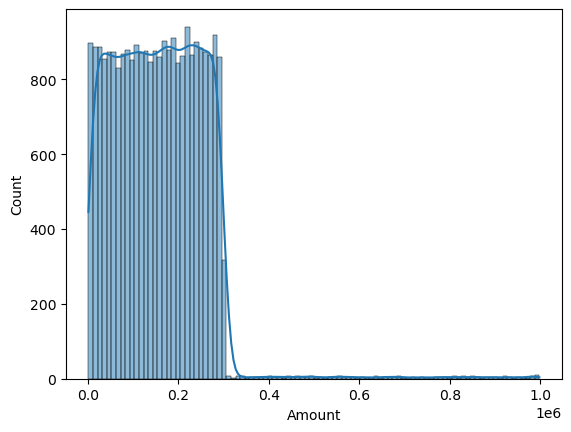

In [37]:
sns.histplot(data=df_1,kde=True)
plt.show()

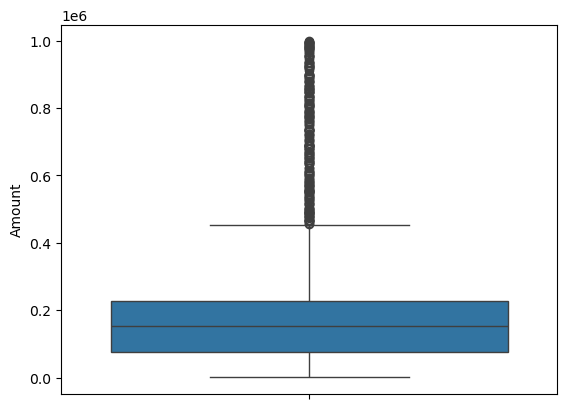

In [38]:
sns.boxplot(data=df_1)
plt.show()

In [39]:
df['Amount'].sort_values(ascending=False)

80       998077.0
134      996754.0
254      996291.0
183      995634.0
330      994537.0
           ...   
6147       1028.0
24958      1026.0
3340       1024.0
18808      1018.0
13444      1005.0
Name: Amount, Length: 26052, dtype: float64

In [41]:
df.sort_values(by='Amount', ascending=False).head(20)

,index,City,City_Tier,Date,Year,Month,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
80,80,"Greater Mumbai, India",Metro,2014-10-14,2014,10,2014Q4,Tuesday,False,True,Platinum,Bills,F,998077.0,Very High
134,134,"Delhi, India",Metro,2013-10-27,2013,10,2013Q4,Sunday,True,True,Gold,Bills,F,996754.0,Very High
254,254,"Ahmedabad, India",Metro,2015-04-17,2015,4,2015Q2,Friday,False,False,Gold,Bills,F,996291.0,Very High
183,183,"Ahmedabad, India",Metro,2014-08-27,2014,8,2014Q3,Wednesday,False,False,Platinum,Bills,F,995634.0,Very High
330,330,"Delhi, India",Metro,2014-06-07,2014,6,2014Q2,Saturday,True,False,Signature,Bills,F,994537.0,Very High
343,343,"Greater Mumbai, India",Metro,2014-09-06,2014,9,2014Q3,Saturday,True,False,Signature,Bills,F,994184.0,Very High
68,68,"Greater Mumbai, India",Metro,2014-03-22,2014,3,2014Q1,Saturday,True,False,Gold,Bills,F,991685.0,Very High
141,141,"Greater Mumbai, India",Metro,2013-10-04,2013,10,2013Q4,Friday,False,True,Gold,Bills,F,990700.0,Very High
28,28,"Bengaluru, India",Metro,2015-01-18,2015,1,2015Q1,Sunday,True,False,Platinum,Bills,F,987935.0,Very High
17,17,"Greater Mumbai, India",Metro,2015-03-30,2015,3,2015Q1,Monday,False,False,Gold,Bills,F,986379.0,Very High


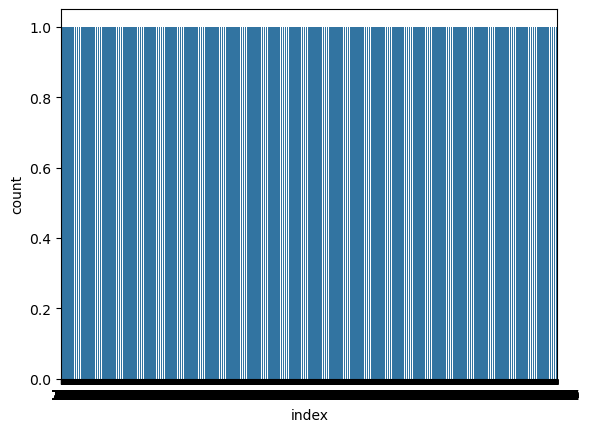

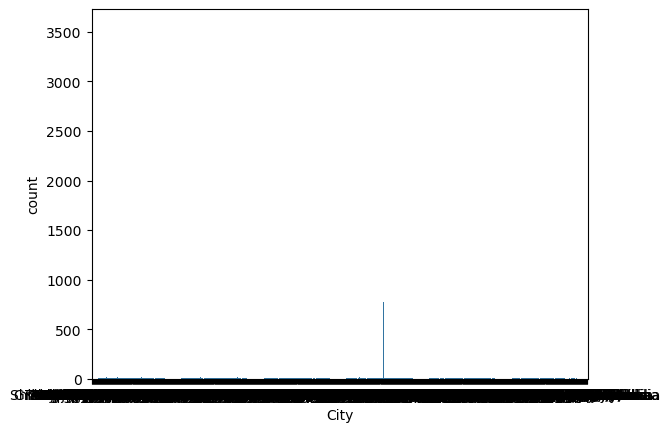

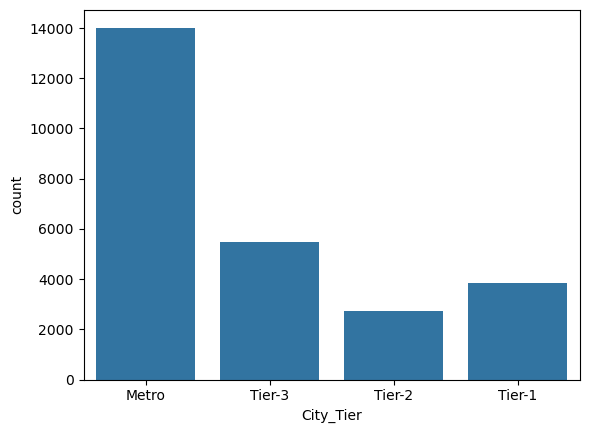

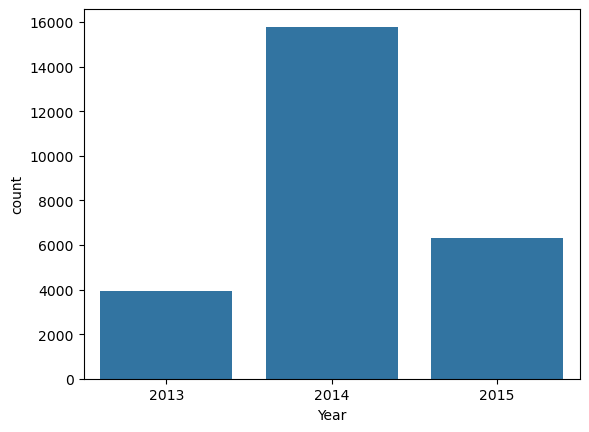

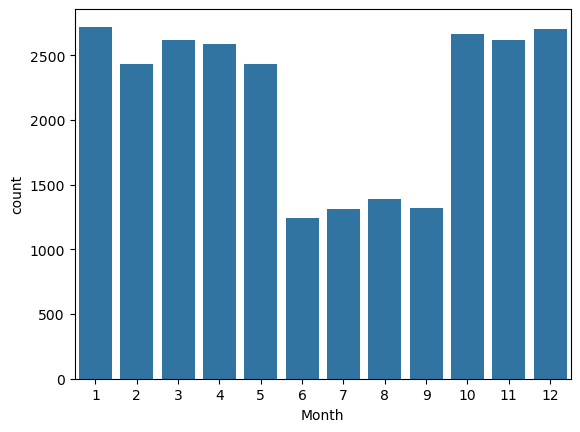

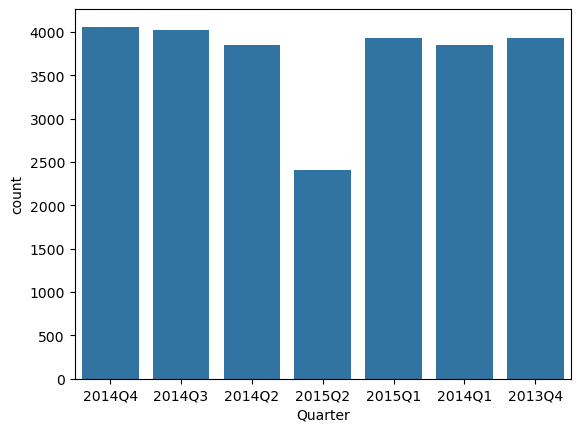

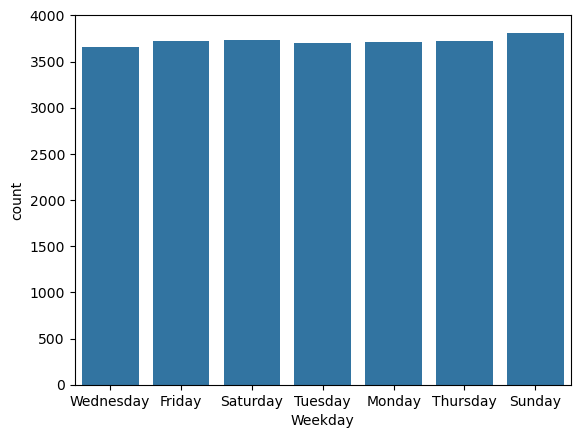

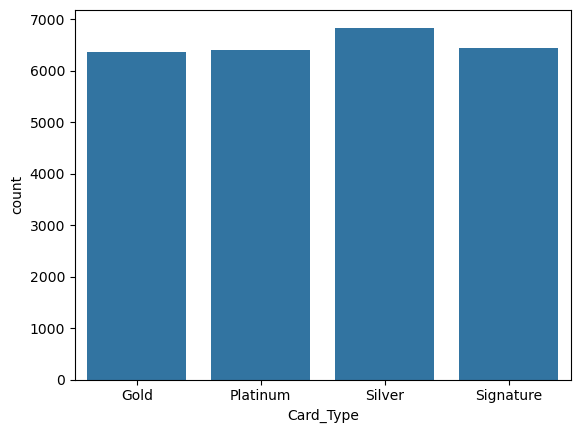

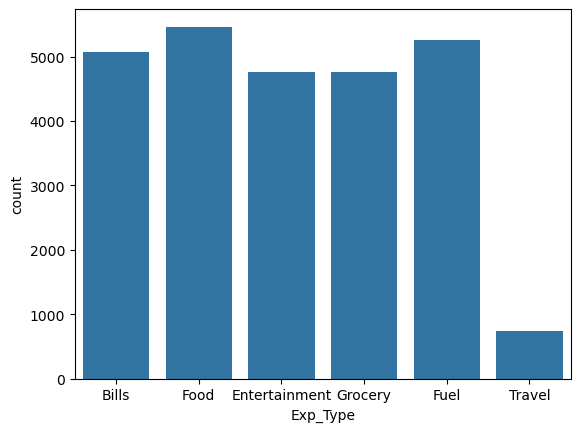

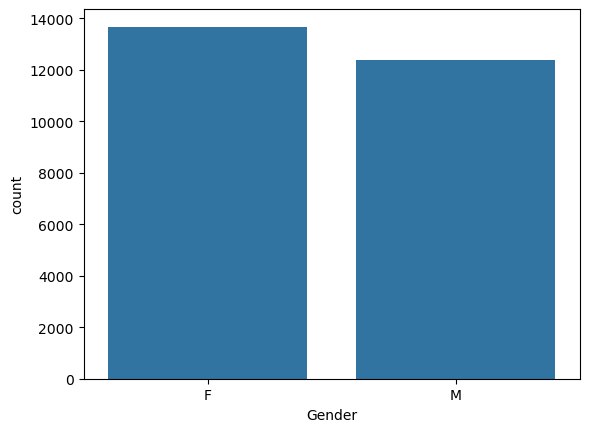

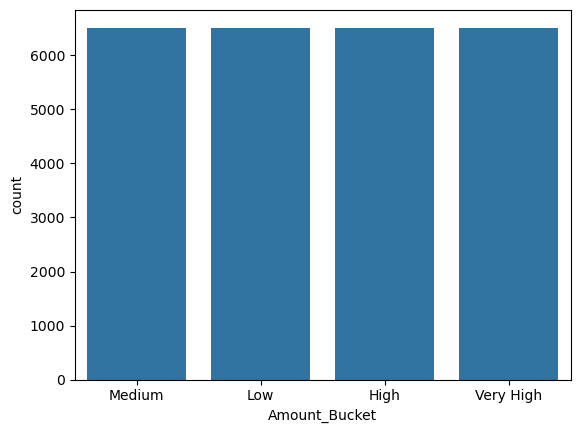

In [40]:
for i in cat_df.columns:
    sns.countplot(data=cat_df,x=i)
    plt.show()

In [42]:
df['Amount'].mean()

np.float64(156411.5374251497)

In [43]:
df['Amount'].median()

153106.5

In [44]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

upper_whisker = df.loc[df['Amount'] <= upper_limit,'Amount'].max()

print(upper_whisker)

451874.0


In [45]:
df[df['Amount']>upper_whisker]

,index,City,City_Tier,Date,Year,Month,Quarter,Weekday,Is_Weekend,Festive_Season,Card_Type,Exp_Type,Gender,Amount,Amount_Bucket
15,15,"Greater Mumbai, India",Metro,2014-11-28,2014,11,2014Q4,Friday,False,True,Platinum,Bills,F,647116.0,Very High
17,17,"Greater Mumbai, India",Metro,2015-03-30,2015,3,2015Q1,Monday,False,False,Gold,Bills,F,986379.0,Very High
19,19,"Greater Mumbai, India",Metro,2013-11-09,2013,11,2013Q4,Saturday,True,True,Platinum,Bills,F,735566.0,Very High
21,21,"Delhi, India",Metro,2014-07-01,2014,7,2014Q3,Tuesday,False,False,Signature,Bills,F,809623.0,Very High
22,22,"Greater Mumbai, India",Metro,2015-03-27,2015,3,2015Q1,Friday,False,False,Silver,Bills,F,467014.0,Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,347,"Ahmedabad, India",Metro,2014-07-07,2014,7,2014Q3,Monday,False,False,Signature,Bills,F,454570.0,Very High
348,348,"Greater Mumbai, India",Metro,2015-01-28,2015,1,2015Q1,Wednesday,False,False,Gold,Bills,F,654519.0,Very High
349,349,"Ahmedabad, India",Metro,2014-06-12,2014,6,2014Q2,Thursday,False,False,Gold,Bills,F,958047.0,Very High
350,350,"Bengaluru, India",Metro,2013-11-03,2013,11,2013Q4,Sunday,True,True,Silver,Bills,F,465281.0,Very High


## Bivariat Analysis

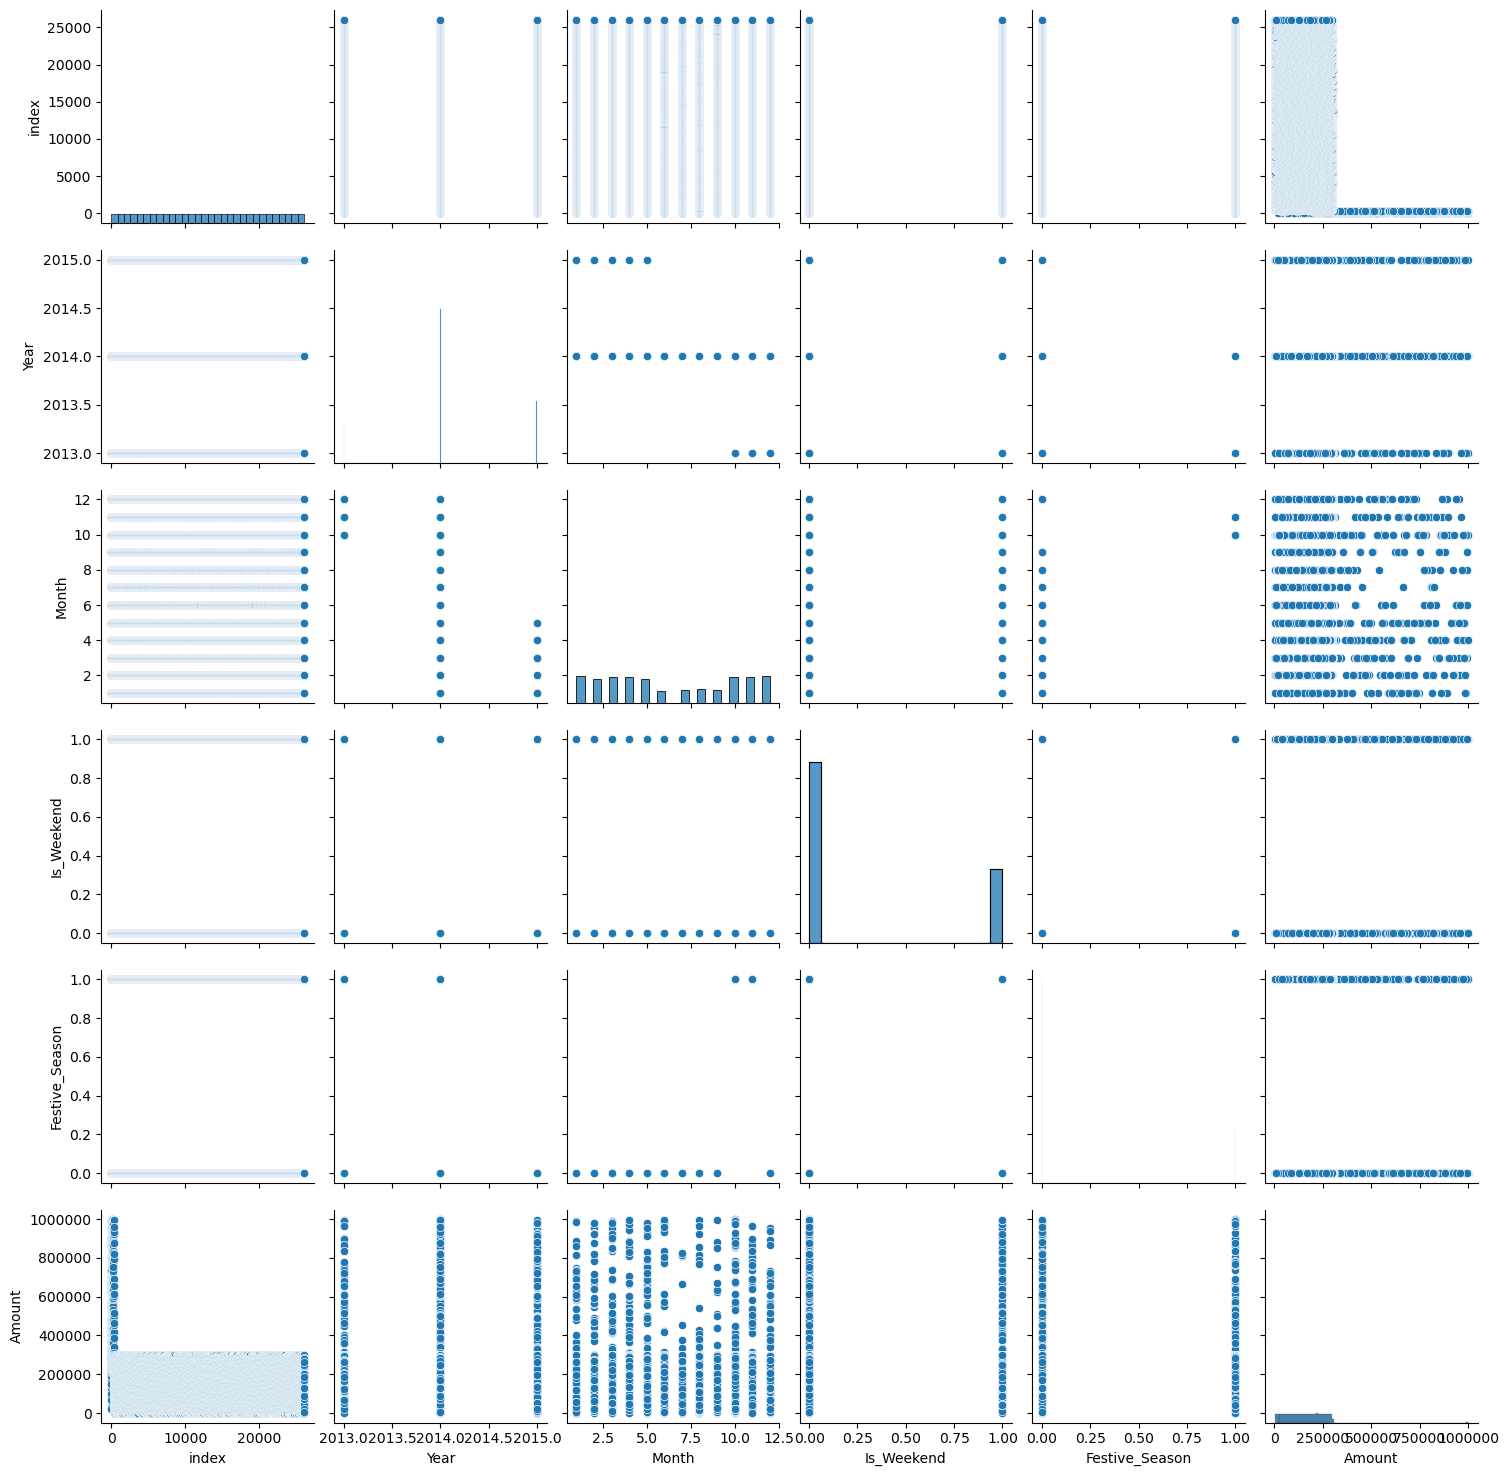

In [46]:
g=sns.pairplot(df)
for ax in g.axes.flat:
    ax.ticklabel_format(style='plain', axis='both')
plt.show()

In [47]:
cor_df=df[['Amount']].corr()

In [48]:
cat_df.columns

Index(['index', 'City', 'City_Tier', 'Year', 'Month', 'Quarter', 'Weekday',
       'Card_Type', 'Exp_Type', 'Gender', 'Amount_Bucket'],
      dtype='object')

In [49]:
df.rename(columns={'Exp Type':'Exp_Type'},inplace=True)

In [50]:
cros_df = pd.crosstab(df['Year'], df['Exp_Type'])

In [51]:
cros_df

Exp_Type,Bills,Entertainment,Food,Fuel,Grocery,Travel
Year,,,,,,
2013,771,733,826,752,739,106
2014,3077,2930,3268,3218,2847,451
2015,1230,1099,1369,1287,1168,181


In [52]:
cros_dfd=cros_df.astype(int)

<Axes: xlabel='Exp_Type', ylabel='Year'>

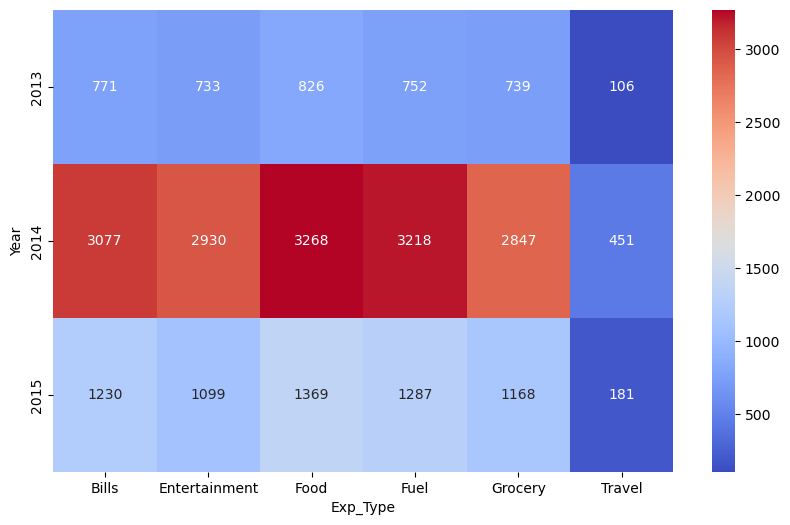

In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(data=cros_df,annot=True,fmt='d',cmap='coolwarm')

## Checking for outliers

In [54]:
num_df=df.select_dtypes(include='number')

In [55]:
num_df


,Amount
0,82475.0
1,32555.0
2,101738.0
3,123424.0
4,171574.0
...,...
26047,128191.0
26048,246316.0
26049,265019.0
26050,88174.0


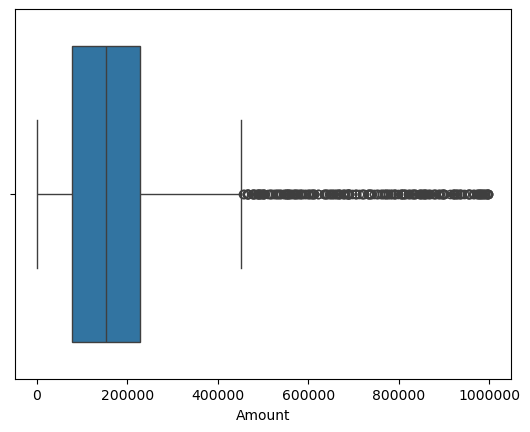

In [56]:
for i in ['Amount']:
    sns.boxplot(data=num_df,x=i)
    plt.ticklabel_format(style='plain', axis='x') ## added 
    plt.show()

## converting file to CSV :

In [57]:
df.to_csv('/Users/sushantsolanki/Desktop/all folders/Finance project/CreditCard_Analytics_Project.csv', index=False)

In [58]:
os.path.exists('/Users/sushantsolanki/Desktop/all folders/Finance project/CreditCard_Analytics_Project.csv')

True

In [59]:
print(os.path.abspath('/Users/sushantsolanki/Desktop/all folders/Finance project/CreditCard_Analytics_Project.csv'))

/Users/sushantsolanki/Desktop/all folders/Finance project/CreditCard_Analytics_Project.csv
